In [1]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.datasets import make_blobs, make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, PolynomialFeatures
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error
from scipy.spatial.distance import cosine
import pandas as pd
import time

In [2]:
df = pd.read_csv('ToyotaCorolla.csv')
df.info()
df.columns


<class 'pandas.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 39 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Id                 1436 non-null   int64
 1   Model              1436 non-null   str  
 2   Price              1436 non-null   int64
 3   Age_08_04          1436 non-null   int64
 4   Mfg_Month          1436 non-null   int64
 5   Mfg_Year           1436 non-null   int64
 6   KM                 1436 non-null   int64
 7   Fuel_Type          1436 non-null   str  
 8   HP                 1436 non-null   int64
 9   Met_Color          1436 non-null   int64
 10  Color              1436 non-null   str  
 11  Automatic          1436 non-null   int64
 12  CC                 1436 non-null   int64
 13  Doors              1436 non-null   int64
 14  Cylinders          1436 non-null   int64
 15  Gears              1436 non-null   int64
 16  Quarterly_Tax      1436 non-null   int64
 17  Weight             1436 n

Index(['Id', 'Model', 'Price', 'Age_08_04', 'Mfg_Month', 'Mfg_Year', 'KM',
       'Fuel_Type', 'HP', 'Met_Color', 'Color', 'Automatic', 'CC', 'Doors',
       'Cylinders', 'Gears', 'Quarterly_Tax', 'Weight', 'Mfr_Guarantee',
       'BOVAG_Guarantee', 'Guarantee_Period', 'ABS', 'Airbag_1', 'Airbag_2',
       'Airco', 'Automatic_airco', 'Boardcomputer', 'CD_Player',
       'Central_Lock', 'Powered_Windows', 'Power_Steering', 'Radio',
       'Mistlamps', 'Sport_Model', 'Backseat_Divider', 'Metallic_Rim',
       'Radio_cassette', 'Parking_Assistant', 'Tow_Bar'],
      dtype='str')

In [3]:

df.describe()



,Id,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,HP,Met_Color,Automatic,CC,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,...,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000
mean,721.555014,10730.824513,55.947075,5.548747,1999.625348,68533.259749,101.502089,0.674791,0.055710,1576.85585,...,0.561978,0.977716,0.146240,0.256964,0.300139,0.770195,0.204735,0.145543,0.002786,0.277855
std,416.476890,3626.964585,18.599988,3.354085,1.540722,37506.448872,14.981080,0.468616,0.229441,424.38677,...,0.496317,0.147657,0.353469,0.437111,0.458478,0.420854,0.403649,0.352770,0.052723,0.448098
min,1.000000,4350.000000,1.000000,1.000000,1998.000000,1.000000,69.000000,0.000000,0.000000,1300.00000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,361.750000,8450.000000,44.000000,3.000000,1998.000000,43000.000000,90.000000,0.000000,0.000000,1400.00000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,721.500000,9900.000000,61.000000,5.000000,1999.000000,63389.500000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,1081.250000,11950.000000,70.000000,8.000000,2001.000000,87020.750000,110.000000,1.000000,0.000000,1600.00000,...,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000
max,1442.000000,32500.000000,80.000000,12.000000,2004.000000,243000.000000,192.000000,1.000000,1.000000,16000.00000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [4]:
df.columns.notna()
df.isnull().sum()

Id                   0
Model                0
Price                0
Age_08_04            0
Mfg_Month            0
Mfg_Year             0
KM                   0
Fuel_Type            0
HP                   0
Met_Color            0
Color                0
Automatic            0
CC                   0
Doors                0
Cylinders            0
Gears                0
Quarterly_Tax        0
Weight               0
Mfr_Guarantee        0
BOVAG_Guarantee      0
Guarantee_Period     0
ABS                  0
Airbag_1             0
Airbag_2             0
Airco                0
Automatic_airco      0
Boardcomputer        0
CD_Player            0
Central_Lock         0
Powered_Windows      0
Power_Steering       0
Radio                0
Mistlamps            0
Sport_Model          0
Backseat_Divider     0
Metallic_Rim         0
Radio_cassette       0
Parking_Assistant    0
Tow_Bar              0
dtype: int64

In [5]:
df.head(5)

,Id,Model,Price,Age_08_04,Mfg_Month,Mfg_Year,KM,Fuel_Type,HP,Met_Color,...,Powered_Windows,Power_Steering,Radio,Mistlamps,Sport_Model,Backseat_Divider,Metallic_Rim,Radio_cassette,Parking_Assistant,Tow_Bar
0,1,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13500,23,10,2002,46986,Diesel,90,1,...,1,1,0,0,0,1,0,0,0,0
1,2,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13750,23,10,2002,72937,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
2,3,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,13950,24,9,2002,41711,Diesel,90,1,...,0,1,0,0,0,1,0,0,0,0
3,4,TOYOTA Corolla 2.0 D4D HATCHB TERRA 2/3-Doors,14950,26,7,2002,48000,Diesel,90,0,...,0,1,0,0,0,1,0,0,0,0
4,5,TOYOTA Corolla 2.0 D4D HATCHB SOL 2/3-Doors,13750,30,3,2002,38500,Diesel,90,0,...,1,1,0,1,0,1,0,0,0,0


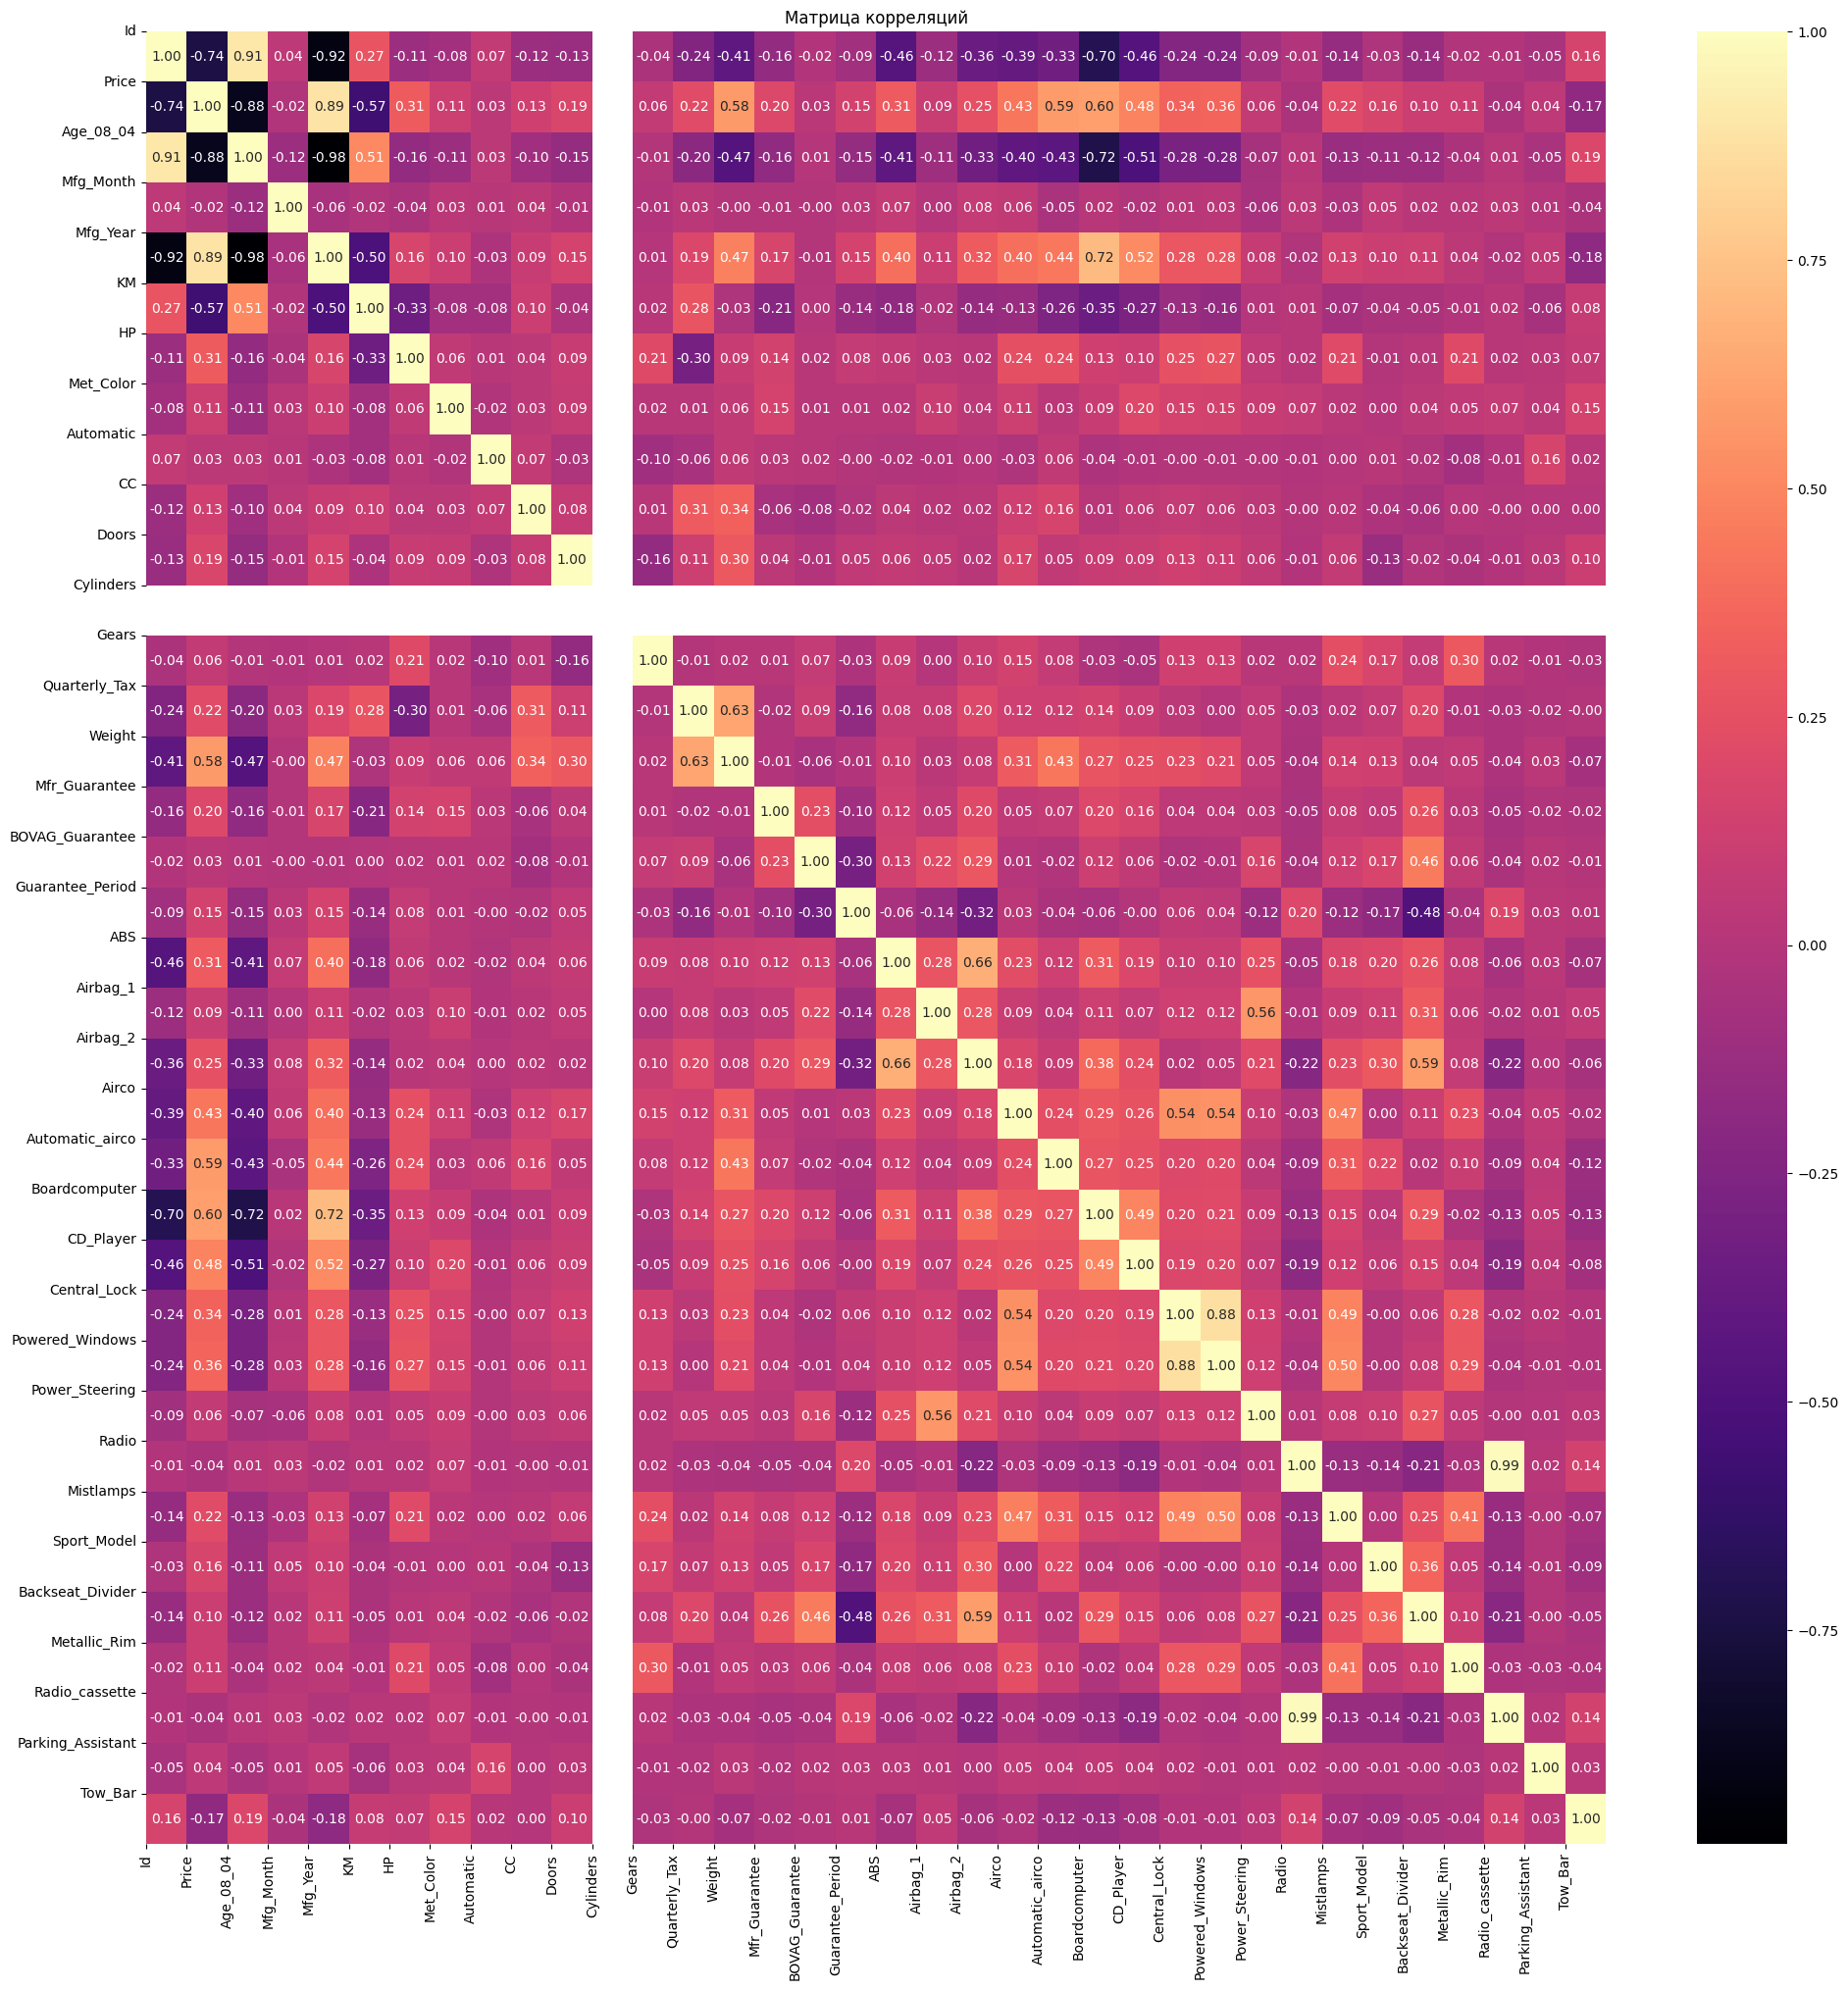

In [6]:

#corr_mat = df.corr(numeric_only=True)
#fig, ax = plt.subplot(figsize=(8, 8))
#sns.heatmap(corr_mat, cmap='magma', annot=True, fmt=".2f")
#plt.xticks(range(len(corr_mat.columns)), corr_mat.columns)
#plt.yticks(range(len(corr_mat.columns)), corr_mat.columns)
#plt.title("Матрица корреляций")
#plt.show()
#print(corr_mat)


corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(24, 24))
sns.heatmap(corr, cmap='magma', annot=True, fmt=".2f")
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Матрица корреляций")
plt.show()

Text(0, 0.5, 'Age')

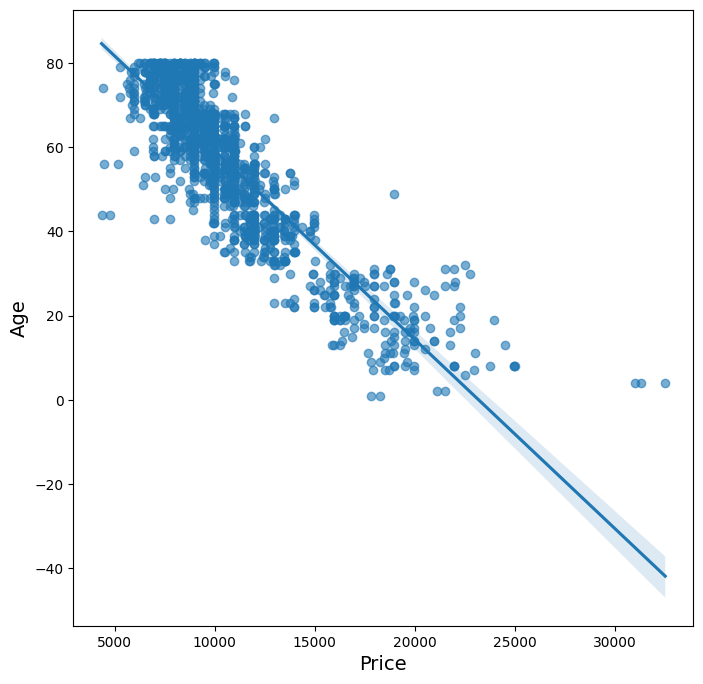

In [7]:
f, axes = plt.subplots(figsize=(8, 8))
sns.regplot(x='Price', y='Age_08_04', data=df, scatter_kws={'alpha':0.6})
axes.set_xlabel('Price', fontsize=14)
axes.set_ylabel('Age', fontsize=14)


In [ ]:

X_prep = df.drop(columns=['Price'])
y = df['Price']

X = pd.get_dummies(X_prep)  
print(X.shape)
X.head(5)

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=101)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(pd.DataFrame(X_train_scaled, columns=X.columns).head())



(1436, 367)
         Id  Age_08_04  Mfg_Month  Mfg_Year        KM        HP  Met_Color  \
0  0.859648   0.801440   1.330222 -1.050497  1.801230 -1.899713  -1.432896   
1  0.217683   0.581437  -1.059598 -0.387876  0.050992  0.561985  -1.432896   
2  1.441504   1.296447  -1.358325 -1.050497 -0.050269  0.561985   0.697887   
3  0.039760   0.251432   0.732767 -0.387876  0.366678  0.561985   0.697887   
4 -0.958051  -0.848584  -0.462143  0.937367 -0.974231  0.561985   0.697887   

   Automatic        CC     Doors  ...  Color_Beige  Color_Black  Color_Blue  \
0  -0.242983  0.899516  1.010021  ...    -0.041776    -0.384708   -0.497821   
1  -0.242983  0.040998  1.010021  ...    -0.041776    -0.384708   -0.497821   
2  -0.242983  0.040998  1.010021  ...    -0.041776    -0.384708    2.008753   
3  -0.242983  0.040998 -1.096253  ...    -0.041776    -0.384708   -0.497821   
4   4.115519  0.040998  1.010021  ...    -0.041776    -0.384708   -0.497821   

   Color_Green  Color_Grey  Color_Red  Color

Я разделил выборку в соотношениии 80-20 (тренировка-тест). Чтобы все категориальные признаки приняли числовое значение, я воспользовался get_dummies , а дальше спокойно разделил сплитом и заскейлил по опыту прошлого дз.  

На тренировочной выборке модель ищет закономерности на основании правильных ответов, а вот на обучающей она проходит тест, учиться применять свои навыки. Если бы она тестировалась, на то что учила, то  она просто подставляла бы знакомые ей ответы, без прокачки "мозга"

In [36]:
#from sklearn.linear_model import LinearRegression, Ridge, Lasso
#from sklearn.metrics import accuracy_score, confusion_matrix, r2_score, mean_absolute_error, mean_squared_error

lnreg = LinearRegression()

start = time.time()
lnreg.fit(X_train_scaled, y_train)
end = time.time()
t_time = end - start
y_pred_train = lnreg.predict(X_train_scaled)
y_pred = lnreg.predict(X_test_scaled)
print(mean_squared_error(y_train, y_pred_train), mean_absolute_error(y_train, y_pred_train), r2_score(y_train, y_pred_train))
print(mean_squared_error(y_test, y_pred), mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred))
print(f"{t_time:.4f} секунд")

513940.1341502619 518.4561165698319 0.95850085191025
2083040.226400411 970.1025917331463 0.869904863098901
0.0403 секунд


In [31]:
from sklearn.pipeline import Pipeline
import time
from sklearn.model_selection import GridSearchCV
pipeline_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

param_grid = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    pipeline_ridge,
    param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
start_time= time.time()
grid.fit(X_train_scaled, y_train)
end_time = time.time()
t_time = end_time - start_time

print(f"Лучшие параметры: {grid.best_params_}")
print(f"Лучшая точность на CV: {grid.best_score_:.4f}")
print(f"Точность на тесте: {grid.score(X_test_scaled, y_test):.4f}")
print(f"Время обучения: {t_time:.4f} секунд")

Лучшие параметры: {'model__alpha': 100}
Лучшая точность на CV: 0.8850
Точность на тесте: 0.8746
Время обучения: 0.2602 секунд


In [32]:
import time
from sklearn.model_selection import GridSearchCV
sl = {'alpha' : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0] }
rid2 = Ridge()
rid_search = GridSearchCV(
    rid2, #оптимизируем модель
    sl,
    scoring='r2',
    n_jobs=-1
)
start_time = time.time()
rid_search.fit(X_train_scaled, y_train)
end_time = time.time()
t_time = end_time - start_time
 

print(f"Лучшие параметры: {rid_search.best_params_}")
print(f"Лучшая точность на CV: {rid_search.best_score_:.4f}")
print(f"Точность на тесте: {rid_search.score(X_test_scaled, y_test):.4f}")
print(f"Время обучения: {t_time:.4f} секунд")

Лучшие параметры: {'alpha': 100.0}
Лучшая точность на CV: 0.8860
Точность на тесте: 0.8746
Время обучения: 0.2115 секунд


In [25]:
rid = Ridge(alpha=100)
rid.fit(X_train_scaled, y_train)
y_pred = rid.predict(X_test_scaled)
print(mean_squared_error(y_test, y_pred), mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred))

2007413.256557915 894.6403782509931 0.8746281040955843


In [37]:
from sklearn.model_selection import GridSearchCV
import time
sl = {'alpha' : [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0] }
las2 = Lasso()
las_search = GridSearchCV(
    las2, #оптимизируем модель
    sl,
    scoring='r2',
    n_jobs=-1
)
start_time = time.time()
las_search.fit(X_train_scaled, y_train) 
end_time = time.time()
t_time = end_time - start_time


print(f"Лучшие параметры: {las_search.best_params_}")
print(f"Лучшая точность на CV: {las_search.best_score_:.4f}")
print(f"Точность на тесте: {las_search.score(X_test_scaled, y_test):.4f}")
print(f"Время обучения: {t_time:.4f} секунд")

Лучшие параметры: {'alpha': 10.0}
Лучшая точность на CV: 0.8875
Точность на тесте: 0.9100
Время обучения: 4.5539 секунд


In [38]:
las = Lasso(alpha=10)

las.fit(X_train_scaled, y_train)

y_pred = las.predict(X_test_scaled)
print(mean_squared_error(y_test, y_pred), mean_absolute_error(y_test, y_pred), r2_score(y_test, y_pred))


1441658.7564973517 814.155542325459 0.9099619916532813


Использовалось аналитическое решение, для оценки качества решения использовались MSE, MAE, R^2

Скорость обучения у LAsso в пять раз больше Ridge (1.0, 0.2 секунд), потому что Lasso имеет итеративный алгоритм , а Ridge аналитический. Но при этом у Лассо работает более качественно. Для достижения максимальноц точности у моделей использовался подбор с помощью GridSearchCV

Пункт 6

1. Использовались метрики MSE, MAEи r2. Целевой метрикой был r2, он показывает точность предсказаний нашей модели линейной регрессии. MSE исползовалось как показатель квадратичной ошибки (взяв аод корень получим RSME), данная метрика более чувствительна к выбросам поэтому мы посчитали ее чтобы видеть как это влияет на наше предсказание, в свою очередь MAE показывает среднюю ошибку в единицах измерения , она менее чувствительна к выбросам, в нашем случае ошибка была в районе 970 долларов (7-10 %) что является неплохим процентом как мне кажется.
2. на тестовой (20% от всей выборки)
3. Lasso справилась лучше, показав лучшую точность, но платой за это является ее более низкая скоротсь (про их разницу я написал выше)
4. Я считаю неплохими, модели обосновывают цену на 87-91 процент, думаю это неплохой результат
5. код ниже показыает что модель не переобучается, т.к результат на тренировочной и тестовой выборке не сильно разнится

In [14]:
y_train_pred = las.predict(X_train_scaled)
y_test_pred = las.predict(X_test_scaled)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(train_r2 - test_r2)

0.0449475784677017
